In [1]:
# ------------------------------------------------------------------ #
#  Notebook 04 · Revenue Forecasting                                 #
#  Input : data/processed/retail_clean.parquet                       #
#  Output: data/processed/forecast.parquet                           #
# ------------------------------------------------------------------ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from prophet import Prophet
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

CLEAN_PATH = r'E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\retail_clean.parquet'
SAVE_PATH  = r'E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\forecast.parquet'

c:\Users\Sujal Dev\envs\master-ds\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_parquet(CLEAN_PATH)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Aggregate to weekly revenue — daily is too noisy for this dataset,
# monthly gives too few data points for Prophet to learn seasonality well.
weekly = (
    df.resample('W', on='InvoiceDate')['Revenue']
    .sum()
    .reset_index()
    .rename(columns={'InvoiceDate': 'ds', 'Revenue': 'y'})
)

# Drop the last week — it is likely partial and would distort the forecast baseline.
weekly = weekly.iloc[:-1]

print(f'Weekly periods : {len(weekly)}')
print(f'Date range     : {weekly.ds.min().date()}  to  {weekly.ds.max().date()}')
print(f'Avg weekly rev : £{weekly.y.mean():,.0f}')
weekly.tail()

Weekly periods : 105
Date range     : 2009-12-06  to  2011-12-04
Avg weekly rev : £158,872


,ds,y
100,2011-11-06,256598.01
101,2011-11-13,259736.76
102,2011-11-20,270225.89
103,2011-11-27,244183.07
104,2011-12-04,247067.39


## 1. STL Decomposition

Before forecasting, we decompose the time series into three components —
trend, seasonality, and residual. This helps us understand the underlying
structure and validate that Prophet will have meaningful patterns to learn.

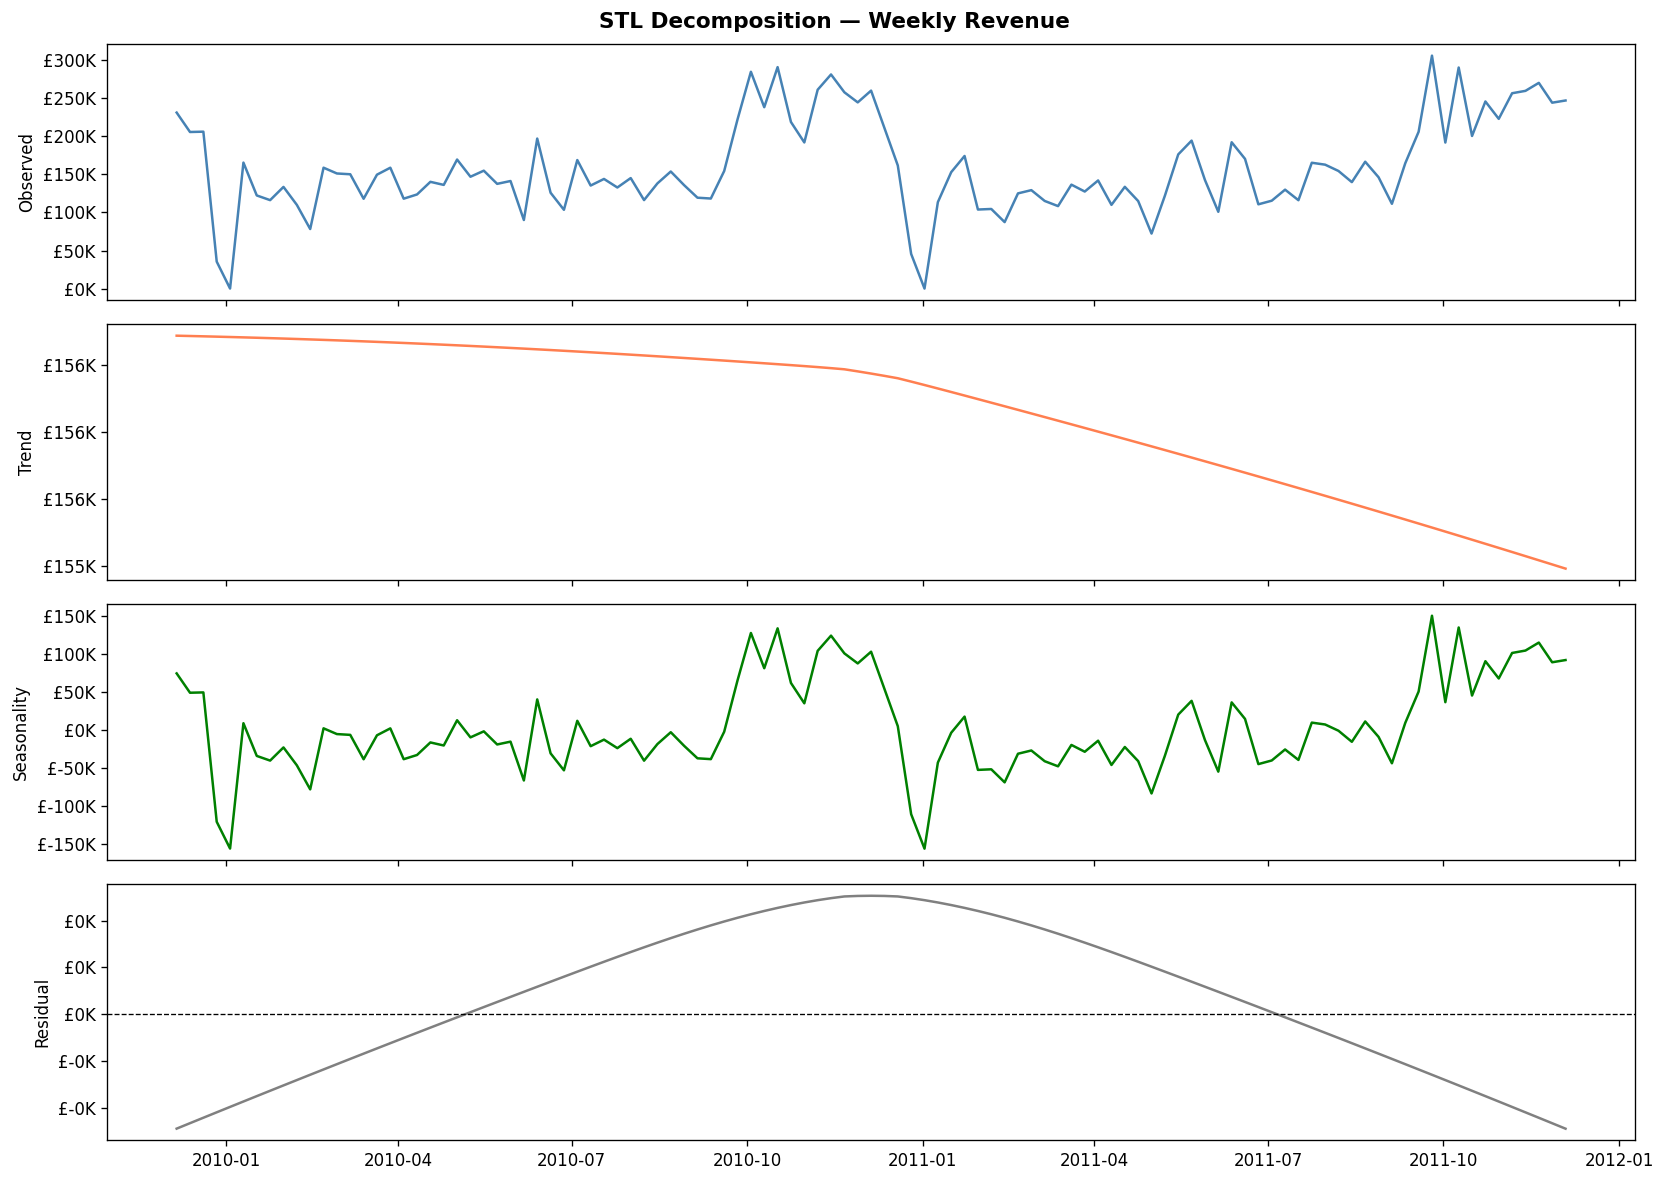

In [3]:
# STL (Seasonal and Trend decomposition using Loess) separates the series
# into trend, weekly seasonality, and remainder (noise).
# period=52 represents one full year of weekly data.

stl = STL(weekly.set_index('ds')['y'], period=52, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(weekly['ds'], weekly['y'], color='steelblue')
axes[0].set_ylabel('Observed')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

axes[1].plot(weekly['ds'], result.trend, color='coral')
axes[1].set_ylabel('Trend')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

axes[2].plot(weekly['ds'], result.seasonal, color='green')
axes[2].set_ylabel('Seasonality')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

axes[3].plot(weekly['ds'], result.resid, color='grey')
axes[3].axhline(0, linestyle='--', linewidth=0.8, color='black')
axes[3].set_ylabel('Residual')
axes[3].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))

fig.suptitle('STL Decomposition — Weekly Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Prophet Forecast

Prophet is trained on the full 105-week history and asked to forecast
12 weeks ahead. We enable yearly seasonality to capture the Q4 pattern
and disable daily seasonality since we are working with weekly data.

In [4]:
# Prophet expects columns named exactly 'ds' and 'y' — already set up in cell 2.
# yearly_seasonality captures the Christmas sales spike we identified earlier.

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # revenue swings scale with the trend level
    interval_width=0.95
)

model.fit(weekly)

# Create 12 weeks of future dates beyond the last data point
future   = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future)

print(f'Forecast rows : {len(forecast)}')
print(f'Forecast end  : {forecast.ds.max().date()}')
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

16:09:48 - cmdstanpy - INFO - Chain [1] start processing
16:09:48 - cmdstanpy - INFO - Chain [1] done processing


Forecast rows : 117
Forecast end  : 2012-02-26


,ds,yhat,yhat_lower,yhat_upper
105,2011-12-11,228000.835572,172483.655148,285031.104517
106,2011-12-18,159150.806574,101052.033775,211215.311248
107,2011-12-25,81067.815996,26327.965570,135625.875770
108,2012-01-01,45468.122195,-9070.965878,101286.989055
109,2012-01-08,73152.442490,18033.992696,125210.972805
110,2012-01-15,129443.779860,73890.383761,181434.542815
111,2012-01-22,158168.751126,100970.018735,212710.574017
112,2012-01-29,138433.425041,85409.797855,197277.047854
113,2012-02-05,101498.038599,50566.878527,155280.650502
114,2012-02-12,91118.104444,38032.175212,143803.055009


## 3. Forecast Visualisation

We plot the full history alongside the 12-week forecast with its
uncertainty interval, then inspect Prophet's learned seasonality components.

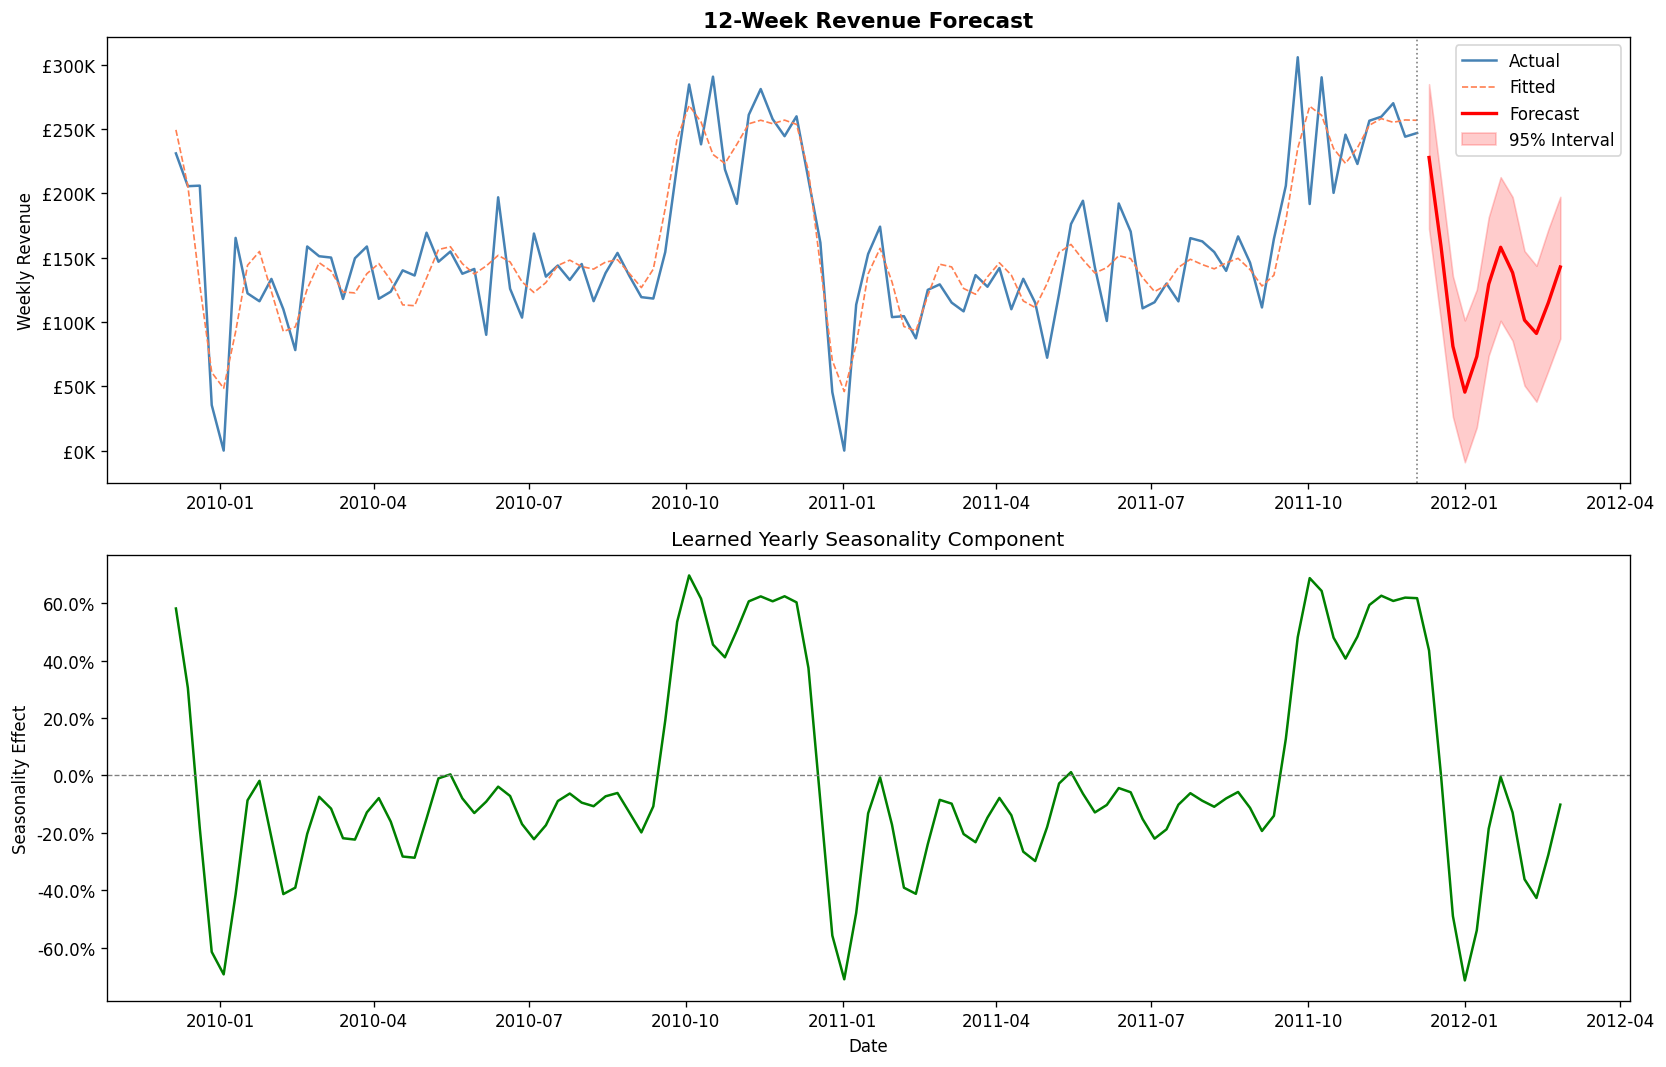

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Forecast plot
history = forecast[forecast['ds'] <= weekly['ds'].max()]
future_fc = forecast[forecast['ds'] > weekly['ds'].max()]

axes[0].plot(weekly['ds'], weekly['y'], color='steelblue', label='Actual', linewidth=1.5)
axes[0].plot(history['ds'], history['yhat'], color='coral', linestyle='--', label='Fitted', linewidth=1)
axes[0].plot(future_fc['ds'], future_fc['yhat'], color='red', label='Forecast', linewidth=2)
axes[0].fill_between(
    future_fc['ds'],
    future_fc['yhat_lower'],
    future_fc['yhat_upper'],
    alpha=0.2, color='red', label='95% Interval'
)
axes[0].axvline(weekly['ds'].max(), linestyle=':', color='grey', linewidth=1)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].set_title('12-Week Revenue Forecast', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Weekly Revenue')
axes[0].legend()

# Yearly seasonality component
yearly = forecast[['ds', 'yearly']].drop_duplicates('ds').sort_values('ds')
axes[1].plot(yearly['ds'], yearly['yearly'], color='green', linewidth=1.5)
axes[1].axhline(0, linestyle='--', linewidth=0.8, color='grey')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1].set_title('Learned Yearly Seasonality Component')
axes[1].set_ylabel('Seasonality Effect')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [6]:
# Save only the columns needed downstream — full forecast table has many
# internal Prophet columns that are not useful in the dashboard.

forecast_out = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'trend', 'yearly']].copy()
forecast_out.columns = ['Date', 'Forecast', 'Lower', 'Upper', 'Trend', 'Seasonality']
forecast_out['Is_Future'] = forecast_out['Date'] > weekly['ds'].max()

forecast_out.to_parquet(SAVE_PATH, index=False)

print(f'Saved : {SAVE_PATH}')
print(f'Rows  : {len(forecast_out)} ({forecast_out["Is_Future"].sum()} forecast weeks)')
forecast_out[forecast_out['Is_Future']].head()

Saved : E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\forecast.parquet
Rows  : 117 (12 forecast weeks)


,Date,Forecast,Lower,Upper,Trend,Seasonality,Is_Future
105,2011-12-11,228000.835572,172483.655148,285031.104517,158900.310304,0.434867,True
106,2011-12-18,159150.806574,101052.033775,211215.311248,158910.786792,0.001510,True
107,2011-12-25,81067.815996,26327.965570,135625.875770,158921.263279,-0.489887,True
108,2012-01-01,45468.122195,-9070.965878,101286.989055,158931.739767,-0.713914,True
109,2012-01-08,73152.442490,18033.992696,125210.972805,158942.216254,-0.539754,True
